# Previsão de CO - Análise Exploratória e Limpeza de Dados

Este notebook corresponde à fase de **análise exploratória e preparação dos dados** do projeto de previsão da concentração de monóxido de carbono (`CO(GT)`), com base no dataset **AirQualityUCI**.

Ao longo deste notebook são realizadas as etapas de inspeção inicial, análise univariada e bivariada, tratamento de valores em falta, verificação de inconsistências, tratamento de outliers, engenharia de atributos e seleção de variáveis. O objetivo é obter um conjunto de dados limpo, coerente e tecnicamente adequado para a fase seguinte de modelação.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

CSV_PATH = "/kaggle/input/datasets/jhonan/airqualityuci/AirQualityUCI.csv"

df = pd.read_csv(CSV_PATH, sep=";", decimal=",")
df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")

print("Dimensão inicial após limpeza estrutural:", df.shape)
display(df.head())

Dimensão inicial após limpeza estrutural: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [2]:
df.info()
display(df.describe(include=[np.number]).T)

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


## Preparação Inicial dos Dados

Nesta fase foi criada uma cópia de trabalho do dataset (`df_clean`) e foram aplicadas transformações iniciais importantes para a análise exploratória.

Em particular:
- os valores `-200` foram convertidos para `NaN`, por representarem ausência de medição;
- as colunas `Date` e `Time` foram combinadas numa variável temporal `timestamp`, permitindo uma representação cronológica mais adequada dos registos.

In [3]:
df_clean = df.copy()

# Substituir -200 por NaN nas colunas numéricas
numeric_cols = [c for c in df_clean.columns if c not in ["Date", "Time"]]
df_clean[numeric_cols] = df_clean[numeric_cols].replace(-200, np.nan)

# Criar timestamp
df_clean["timestamp"] = pd.to_datetime(
    df_clean["Date"].astype(str).str.strip() + " " + df_clean["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Tabela de missing values
missing_table = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_table)

print(df_clean.dtypes)

,missing_count,missing_pct
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S1(CO),366,3.91
T,366,3.91
RH,366,3.91


Date                     object
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
timestamp        datetime64[ns]
dtype: object


## Análise Univariada

Nesta secção são analisadas as variáveis numéricas através de histogramas e boxplots, com o objetivo de compreender a distribuição dos dados, identificar assimetrias e detetar possíveis valores atípicos.

Adicionalmente, é analisada a frequência das variáveis não numéricas `Date` e `Time`, de modo a verificar a regularidade temporal dos registos.

Variáveis numéricas analisadas:
['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


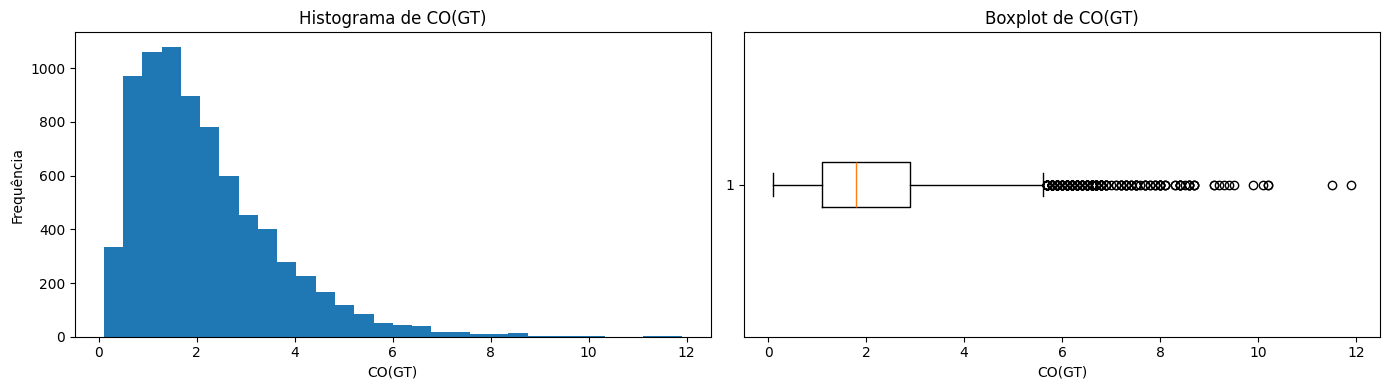

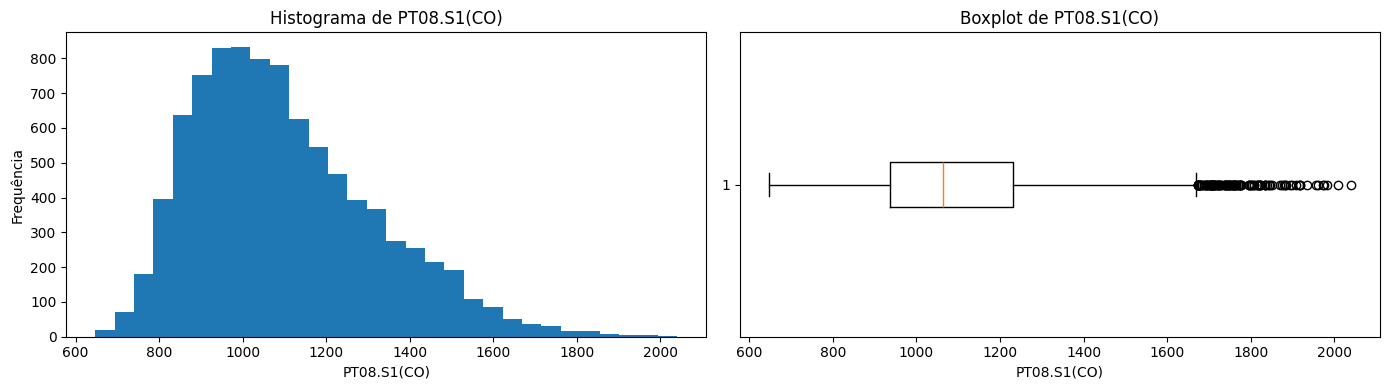

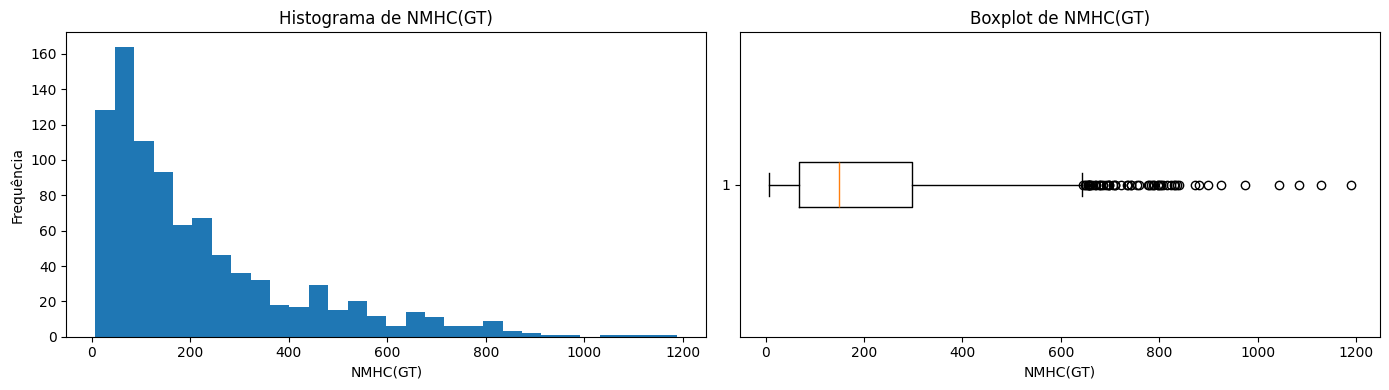

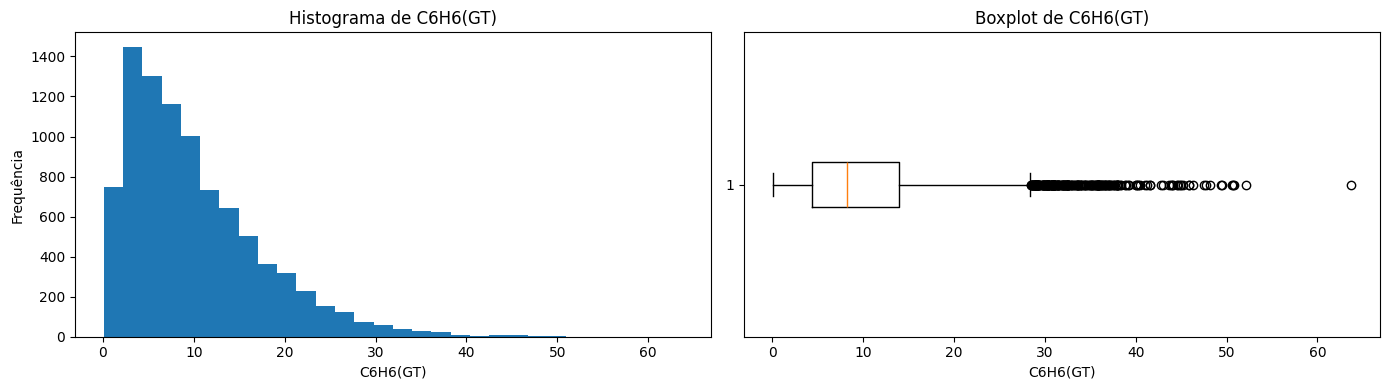

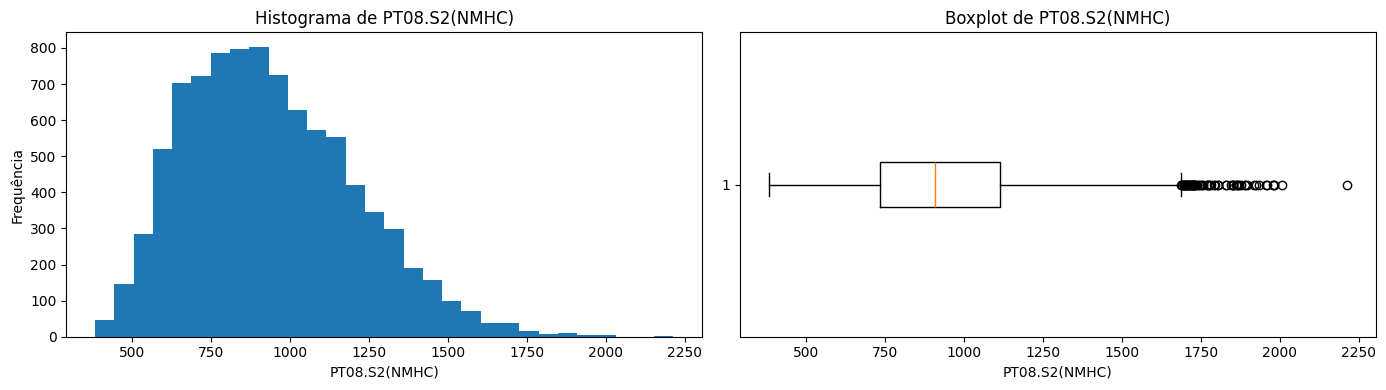

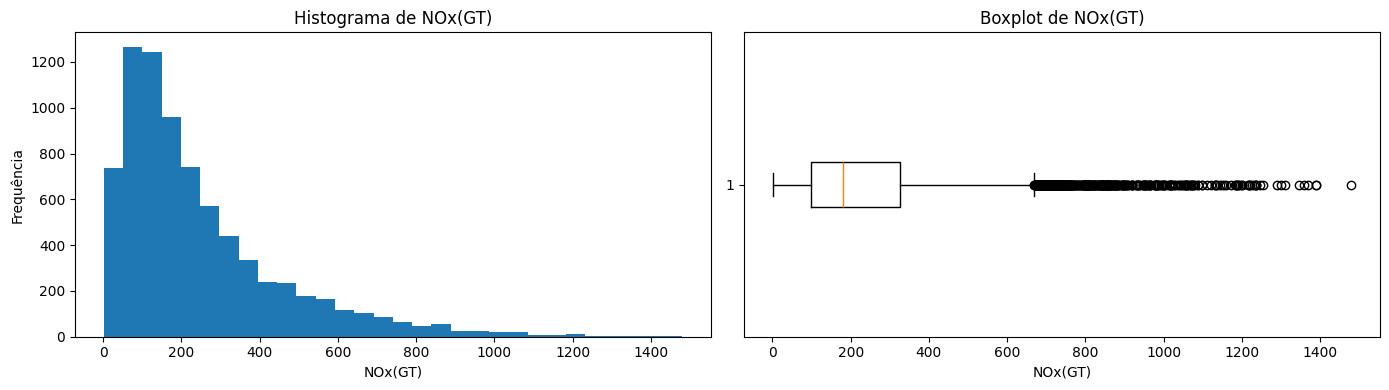

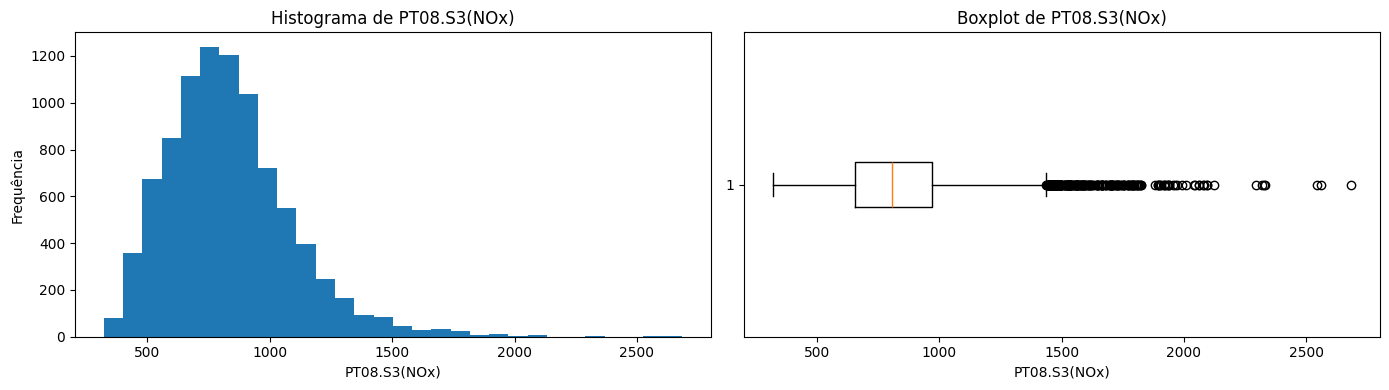

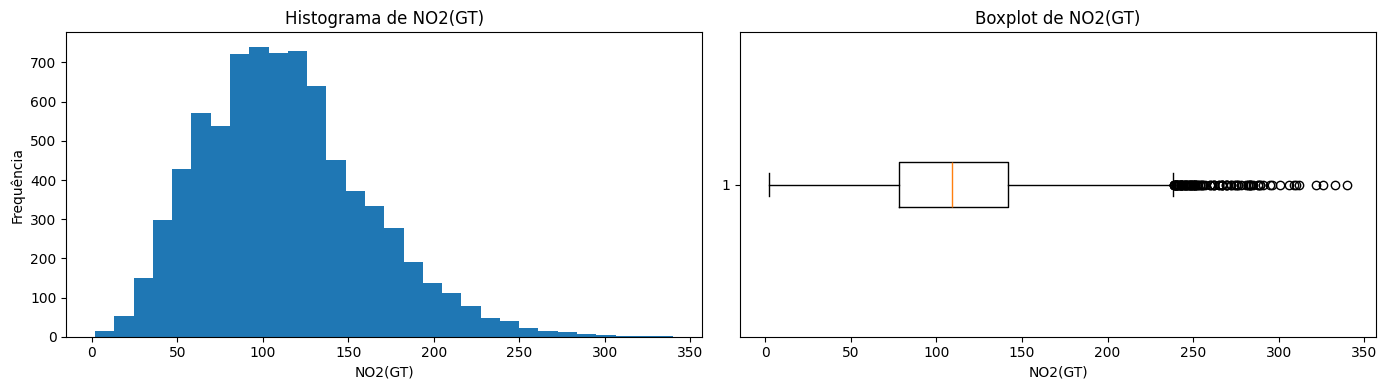

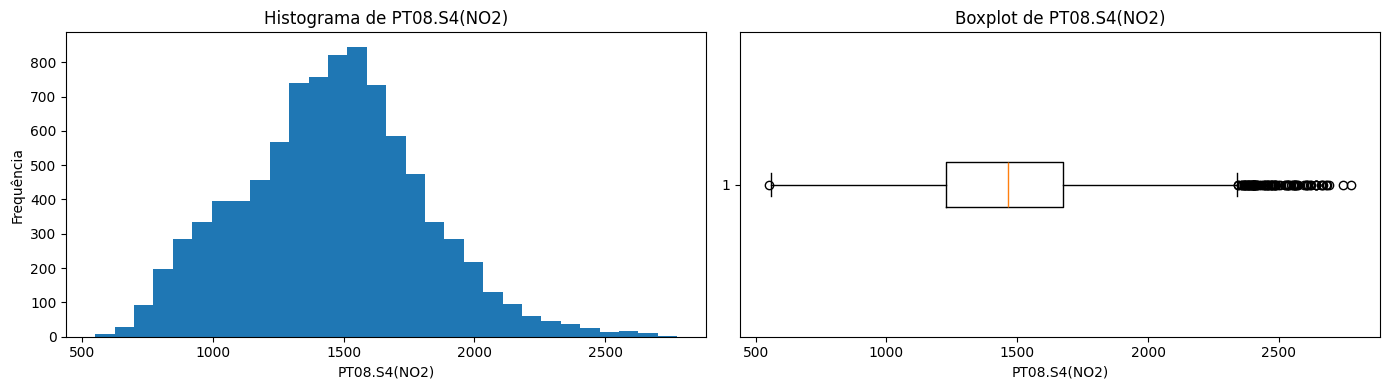

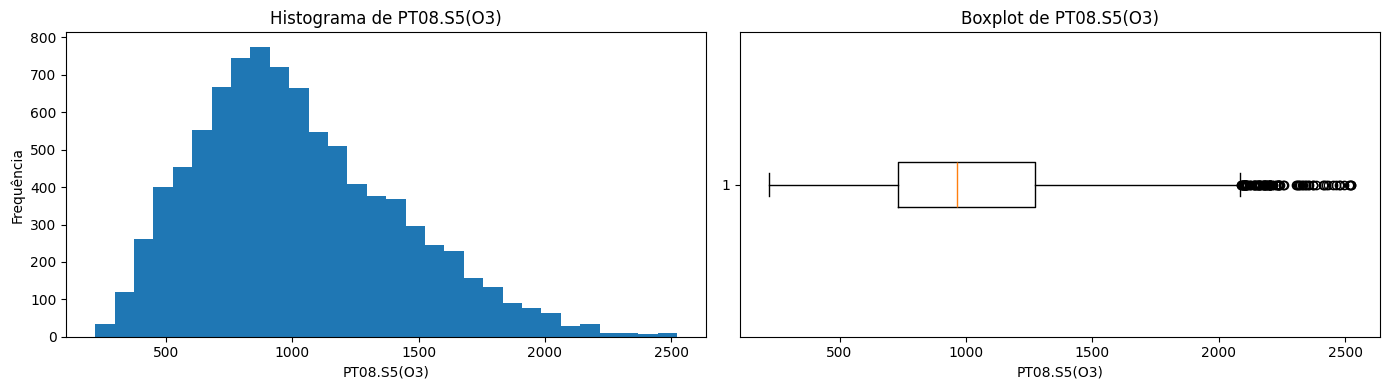

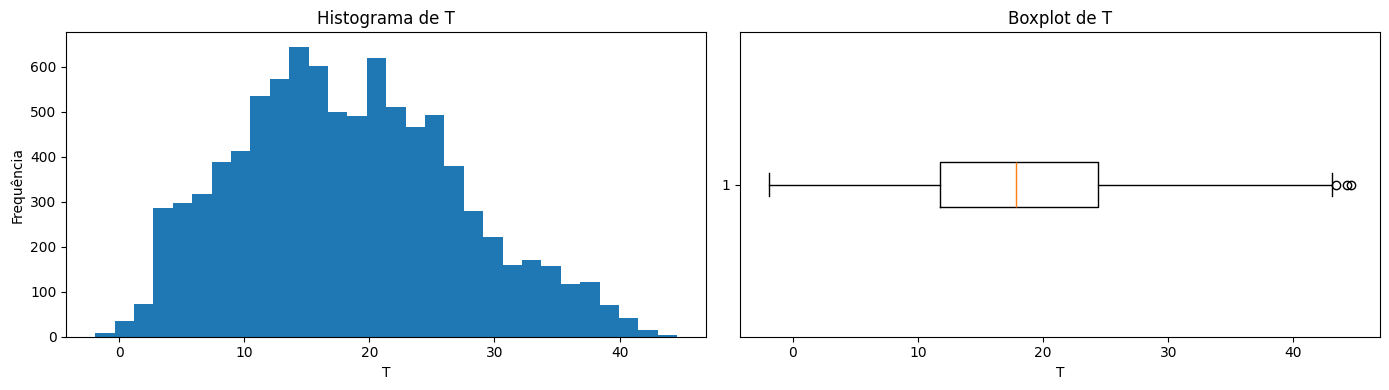

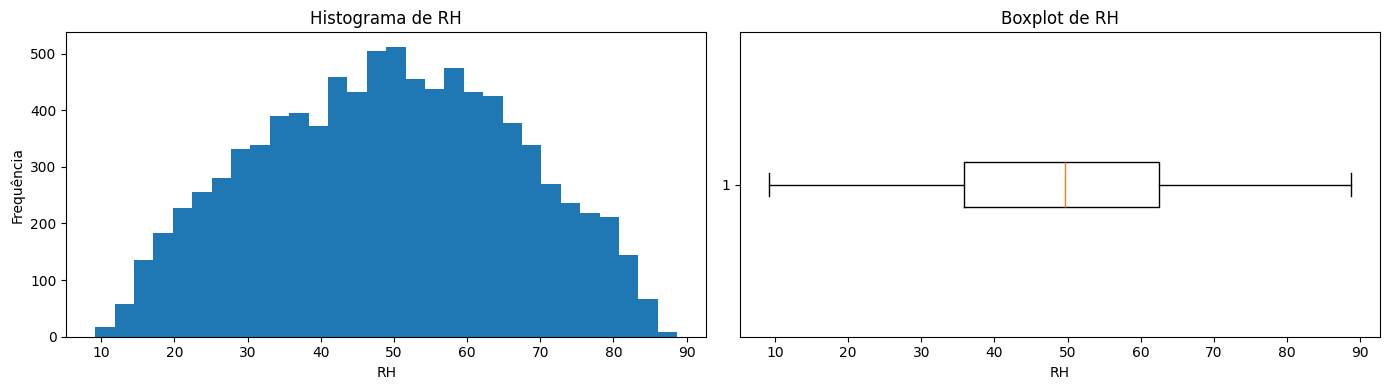

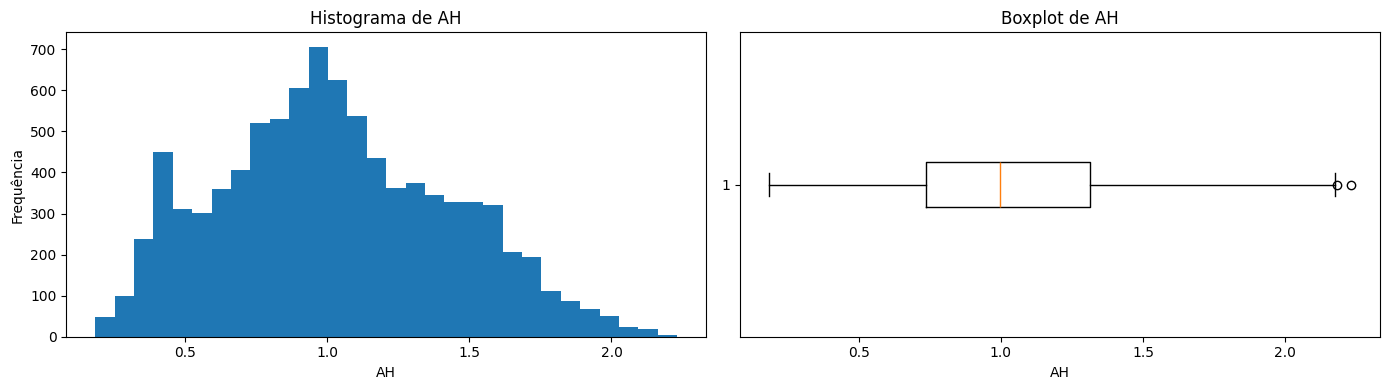

In [4]:
# Selecionar apenas variáveis numéricas
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Variáveis numéricas analisadas:")
print(numeric_features)

# Criar um par de gráficos por variável:
# à esquerda = histograma | à direita = boxplot
for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma
    axes[0].hist(df_clean[col].dropna(), bins=30)
    axes[0].set_title(f"Histograma de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequência")

    # Boxplot
    axes[1].boxplot(df_clean[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


Frequência de day_of_week:


timestamp
Thursday     1344
Friday       1344
Saturday     1344
Sunday       1344
Monday       1335
Wednesday    1326
Tuesday      1320
Name: count, dtype: int64

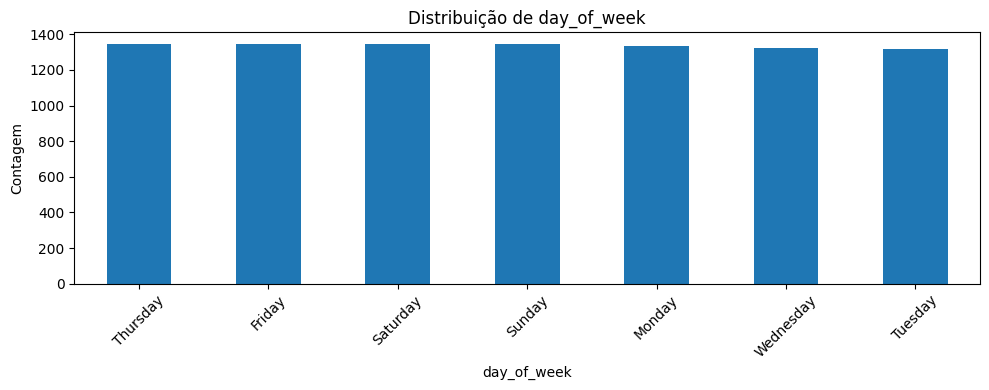


Frequência de month:


timestamp
March        1254
April         807
May           744
July          744
January       744
August        744
October       744
December      744
June          720
September     720
November      720
February      672
Name: count, dtype: int64

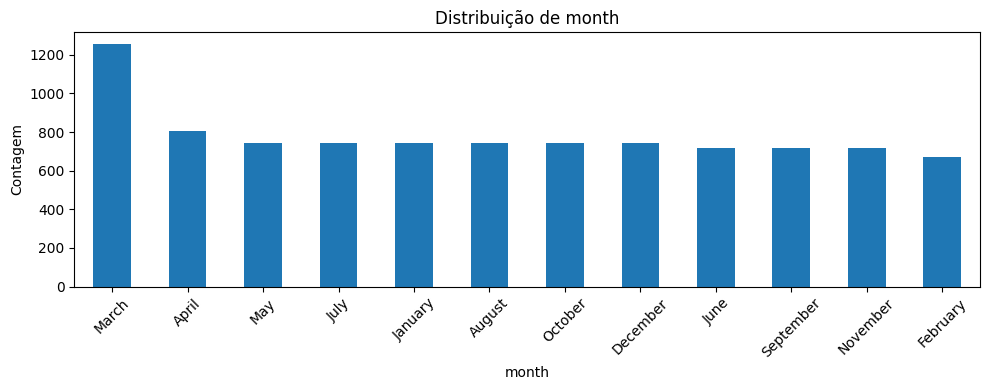

In [5]:
categorical_analysis = {
    "day_of_week": df_clean["timestamp"].dt.day_name(),
    "month": df_clean["timestamp"].dt.month_name()
}

for col_name, series in categorical_analysis.items():
    freq = series.value_counts()

    print(f"\nFrequência de {col_name}:")
    display(freq)

    plt.figure(figsize=(10, 4))
    freq.plot(kind="bar")
    plt.title(f"Distribuição de {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Principais observações da análise univariada

A análise univariada mostrou que a variável-alvo `CO(GT)` apresenta maior concentração de valores baixos e alguns valores mais elevados, o que sugere uma distribuição assimétrica. Os boxplots indicaram também a presença de possíveis outliers em várias variáveis numéricas.

Relativamente às variáveis `Date` e `Time`, a análise de frequência mostrou que o dataset apresenta uma estrutura temporal regular, sendo frequente a existência de 24 registos por dia, o que é consistente com medições horárias.

## Análise Bivariada e Correlações

Nesta secção é analisada a relação entre a variável-alvo `CO(GT)` e os restantes atributos numéricos. Para isso, é utilizada uma matriz de correlação e gráficos de dispersão.

O objetivo é identificar quais as variáveis com maior potencial explicativo para a fase de modelação e compreender a intensidade e o sentido das relações observadas.

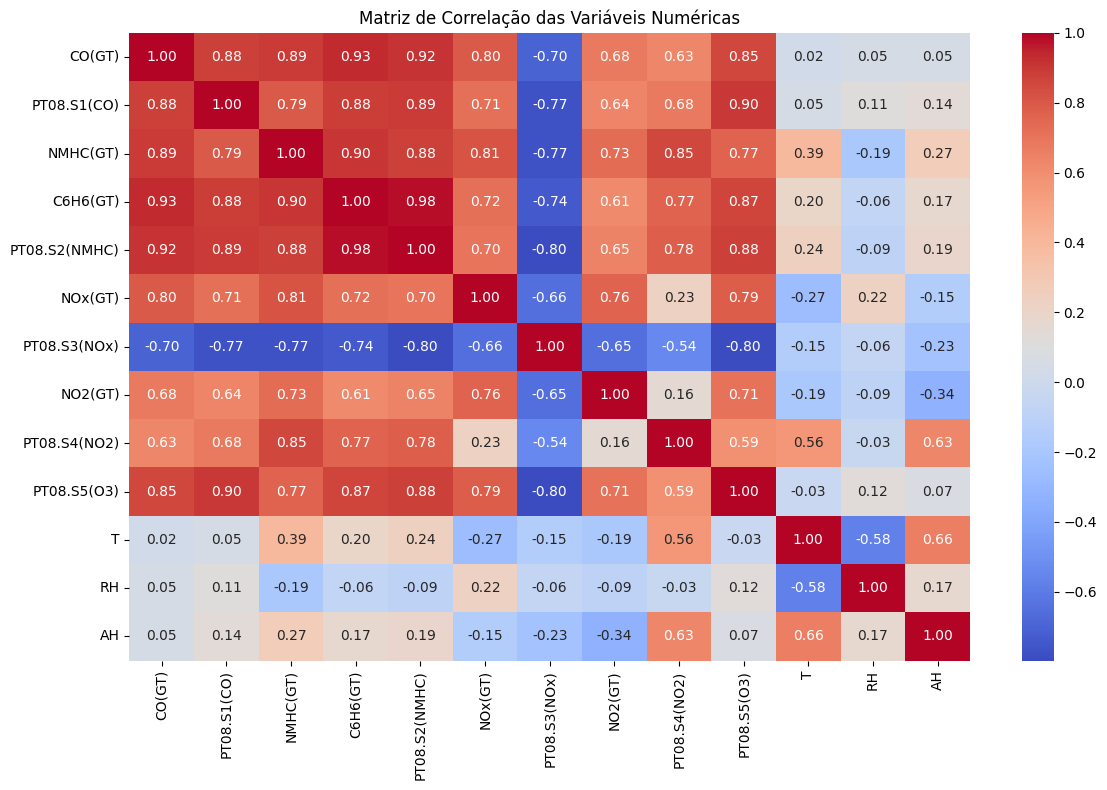

In [6]:
# Selecionar apenas variáveis numéricas
numeric_features = df_clean.select_dtypes(include=[np.number])

# Matriz de correlação
corr_matrix = numeric_features.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()
plt.show()

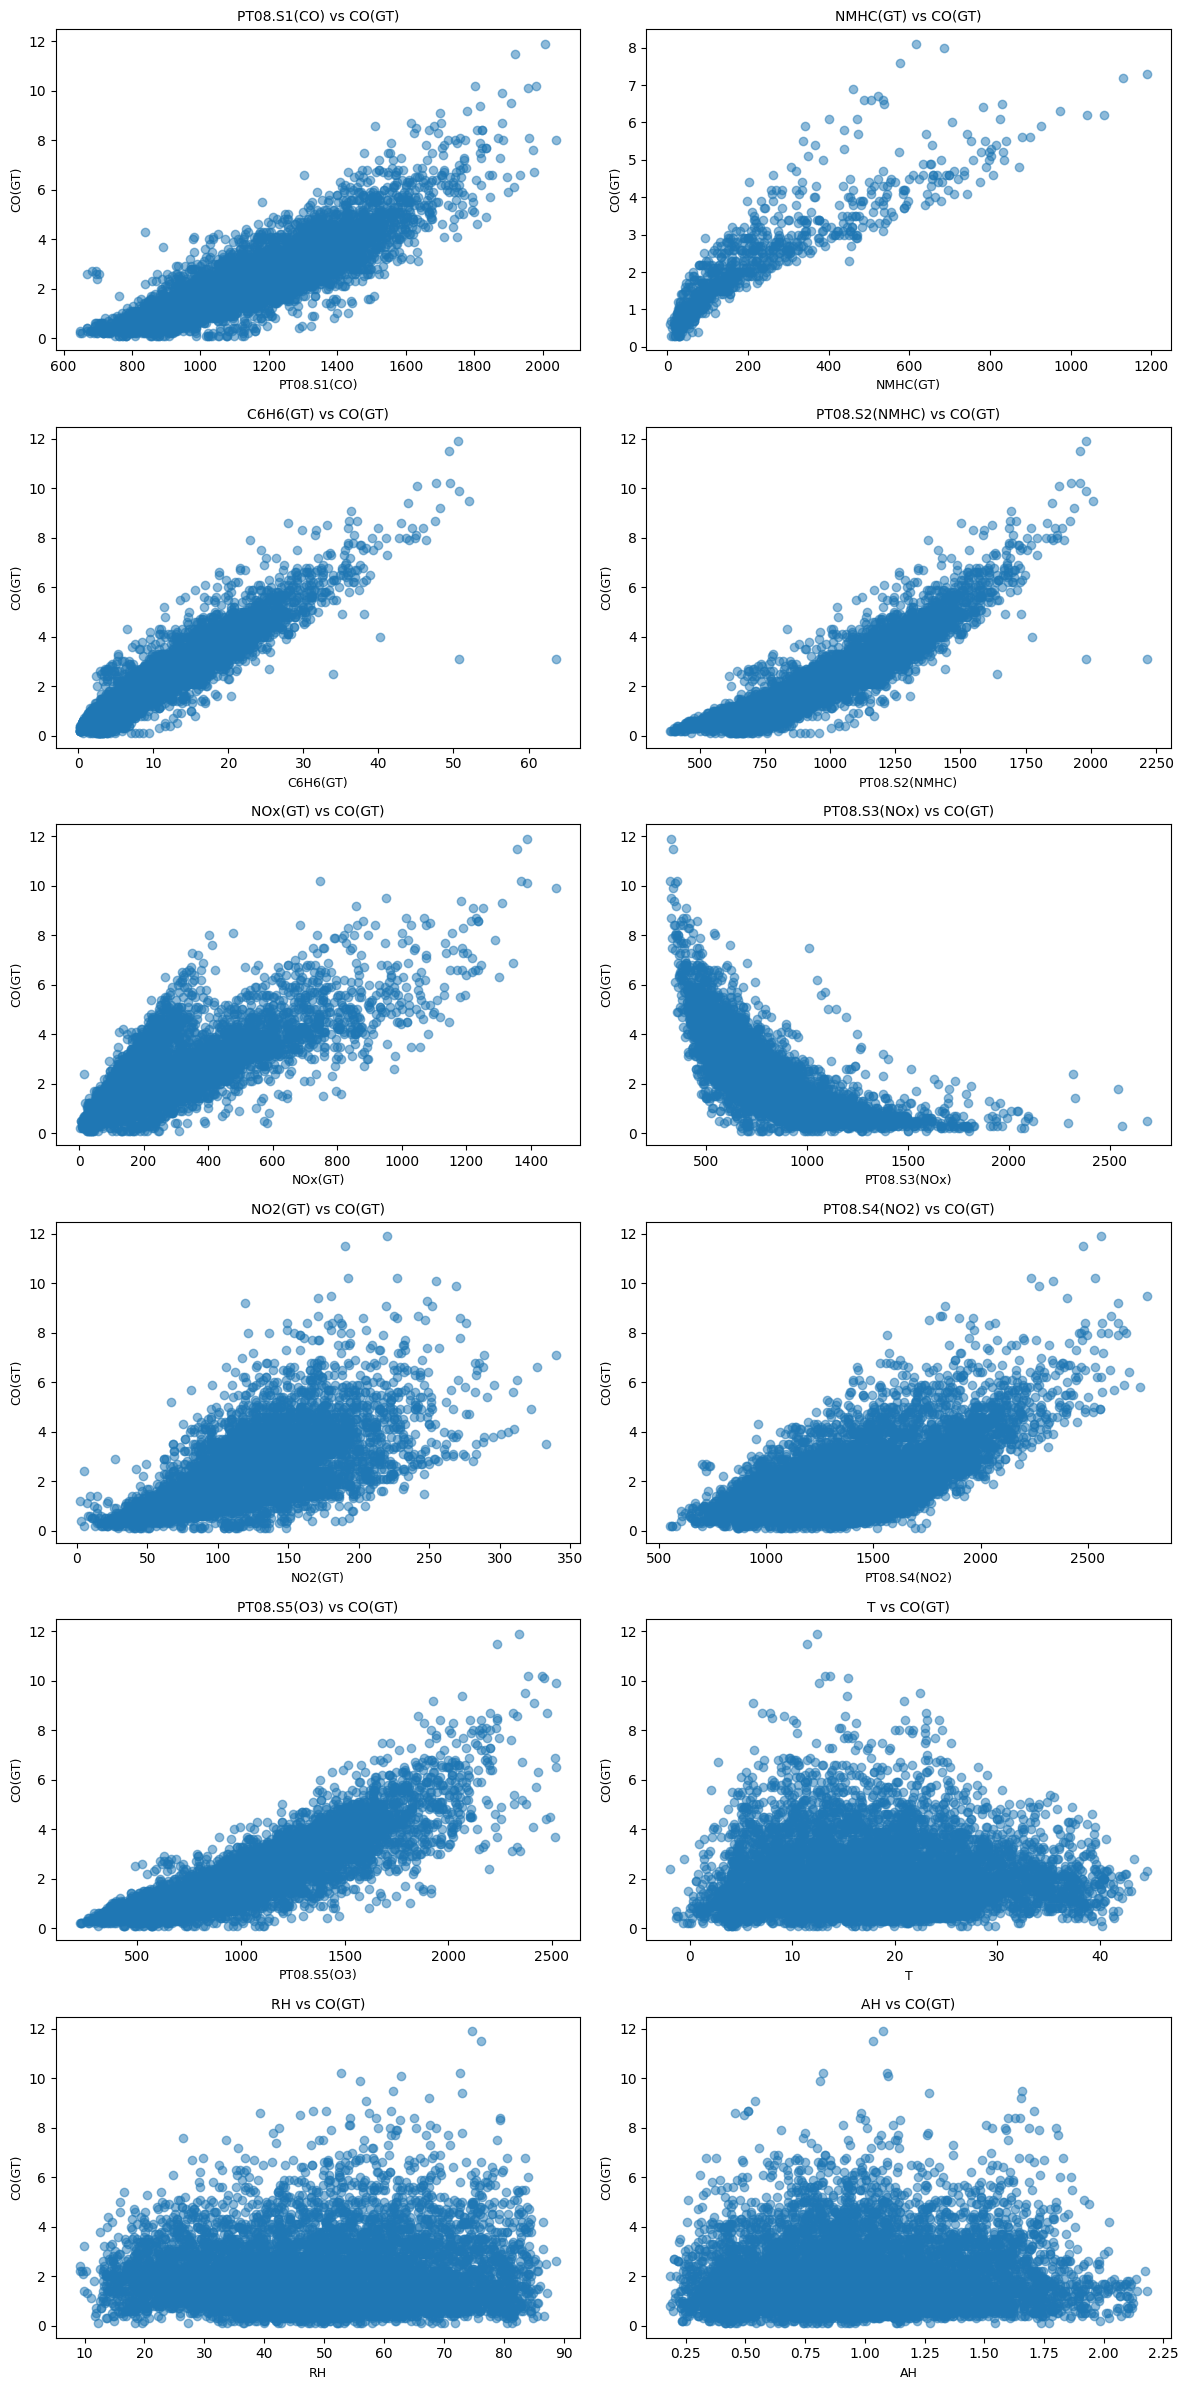

In [7]:
target = "CO(GT)"

# Variáveis numéricas sem a variável-alvo
predictors = [col for col in numeric_features.columns if col != target]

# Número de colunas por linha
n_cols = 2
n_rows = int(np.ceil(len(predictors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(df_clean[col], df_clean[target], alpha=0.5)
    axes[i].set_title(f"{col} vs {target}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(target, fontsize=9)

# Remover gráficos vazios, se existirem
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Principais observações da análise bivariada

A matriz de correlação e os gráficos de dispersão mostram que as variáveis mais fortemente associadas a `CO(GT)` são sobretudo sensores químicos e outros poluentes atmosféricos.

Destacam-se `C6H6(GT)` e `PT08.S2(NMHC)`, que apresentam correlações positivas muito fortes com a variável-alvo, sugerindo elevada utilidade preditiva. A variável `PT08.S3(NOx)` revelou uma relação inversa forte com `CO(GT)`, sendo uma das associações mais evidentes da análise.

Por outro lado, as variáveis meteorológicas `T`, `RH` e `AH` apresentaram correlações fracas e gráficos de dispersão sem padrão visual claro, indicando menor capacidade explicativa isolada.

## Tratamento de Valores em Falta

Nesta secção é analisada a percentagem de valores em falta por coluna, com o objetivo de definir uma estratégia de tratamento adequada ao dataset.

A decisão de tratamento teve em conta a importância das variáveis, a percentagem de dados ausentes e o impacto potencial na modelação.

In [8]:
missing_count = df_clean.isnull().sum()
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_table = pd.DataFrame({
    "Nulos": missing_count,
    "Percentagem (%)": missing_percent.round(2)
}).sort_values(by="Percentagem (%)", ascending=False)

missing_table[missing_table["Nulos"] > 0]

,Nulos,Percentagem (%)
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S1(CO),366,3.91
T,366,3.91
RH,366,3.91


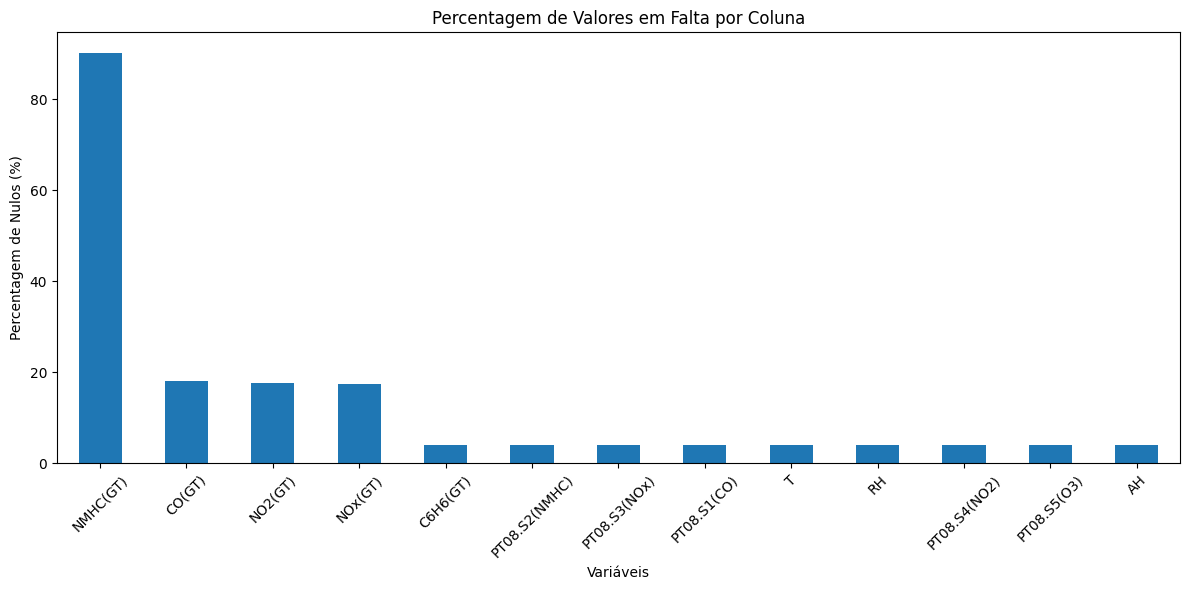

In [9]:
missing_table_filtered = missing_table[missing_table["Nulos"] > 0]

plt.figure(figsize=(12, 6))
missing_table_filtered["Percentagem (%)"].plot(kind="bar")
plt.title("Percentagem de Valores em Falta por Coluna")
plt.xlabel("Variáveis")
plt.ylabel("Percentagem de Nulos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
df_clean = df_clean.drop(columns=["NMHC(GT)"], errors="ignore")
df_clean = df_clean.dropna(subset=["CO(GT)"])

In [11]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != "CO(GT)":
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [12]:
missing_count_final = df_clean.isnull().sum()
missing_percent_final = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_table_final = pd.DataFrame({
    "Nulos": missing_count_final,
    "Percentagem (%)": missing_percent_final.round(2)
}).sort_values(by="Percentagem (%)", ascending=False)

missing_table_final_filtered = missing_table_final[missing_table_final["Nulos"] > 0]

if missing_table_final_filtered.empty:
    print("Não existem valores em falta após o tratamento.")
else:
    display(missing_table_final_filtered)

print("Dimensão final do dataset tratado:", df_clean.shape)

Não existem valores em falta após o tratamento.
Dimensão final do dataset tratado: (7674, 15)


### Principais observações sobre os valores em falta

A análise dos missing values mostrou que a variável `NMHC(GT)` apresentava uma percentagem muito elevada de valores em falta, pelo que foi removida.

As linhas com `CO(GT)` em falta foram eliminadas, por se tratar da variável-alvo, e os restantes valores ausentes foram preenchidos com a mediana. Esta opção foi escolhida por ser mais robusta do que a média na presença de outliers e distribuições assimétricas.

Após a aplicação desta estratégia, deixaram de existir valores em falta no conjunto de dados.

## Verificação de Tipos de Dados e Tratamento de Outliers

Nesta secção são verificados os tipos de dados do dataset e identificados valores atípicos nas variáveis numéricas.

O objetivo é reduzir o impacto de observações extremas que possam enviesar os modelos, mantendo ao mesmo tempo a maior quantidade possível de informação útil.

In [13]:
#Garantir que a coluna temporal está em formato datetime
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

# Garantir que as variáveis numéricas estão em formato numérico
for col in df_clean.columns:
    if col not in ["Date", "Time", "timestamp"]:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean.dtypes

Date                     object
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
timestamp        datetime64[ns]
dtype: object

In [14]:
outlier_summary = []

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
    percent_outliers = (outliers / len(df_clean)) * 100

    outlier_summary.append({
        "Variável": col,
        "Nº de Outliers": outliers,
        "Percentagem (%)": round(percent_outliers, 2)
    })

outlier_table = pd.DataFrame(outlier_summary).sort_values(by="Percentagem (%)", ascending=False)

outlier_table

,Variável,Nº de Outliers,Percentagem (%)
4,NOx(GT),464,6.05
5,PT08.S3(NOx),226,2.95
0,CO(GT),215,2.80
2,C6H6(GT),212,2.76
6,NO2(GT),145,1.89
1,PT08.S1(CO),119,1.55
8,PT08.S5(O3),90,1.17
7,PT08.S4(NO2),80,1.04
3,PT08.S2(NMHC),68,0.89
11,AH,46,0.60


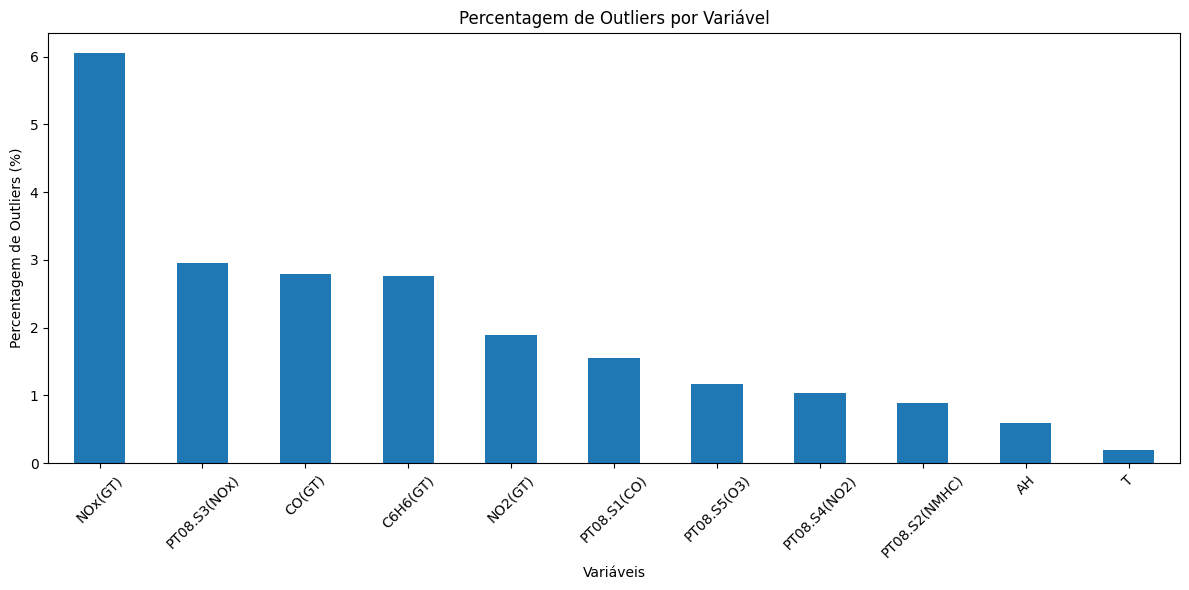

In [15]:
outlier_table_filtered = outlier_table[outlier_table["Nº de Outliers"] > 0]

plt.figure(figsize=(12, 6))
outlier_table_filtered.set_index("Variável")["Percentagem (%)"].plot(kind="bar")
plt.title("Percentagem de Outliers por Variável")
plt.xlabel("Variáveis")
plt.ylabel("Percentagem de Outliers (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outliers.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != "CO(GT)":
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

In [17]:
outlier_summary_final = []

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
    percent_outliers = (outliers / len(df_clean)) * 100

    outlier_summary_final.append({
        "Variável": col,
        "Nº de Outliers": outliers,
        "Percentagem (%)": round(percent_outliers, 2)
    })

outlier_table_final = pd.DataFrame(outlier_summary_final).sort_values(by="Percentagem (%)", ascending=False)

outlier_table_final

,Variável,Nº de Outliers,Percentagem (%)
0,CO(GT),215,2.8
1,PT08.S1(CO),0,0.0
2,C6H6(GT),0,0.0
3,PT08.S2(NMHC),0,0.0
4,NOx(GT),0,0.0
5,PT08.S3(NOx),0,0.0
6,NO2(GT),0,0.0
7,PT08.S4(NO2),0,0.0
8,PT08.S5(O3),0,0.0
9,T,0,0.0


### Principais observações sobre outliers e consistência dos dados

Foi confirmada a consistência dos tipos de dados, mantendo `timestamp` em formato temporal e as restantes variáveis quantitativas em formato numérico.

Os outliers foram identificados através do método do intervalo interquartil (IQR), por se tratar de uma abordagem robusta para variáveis numéricas contínuas. Nesta fase, optou-se por privilegiar uma abordagem quantitativa, com base na contagem e percentagem de valores atípicos por variável, evitando a repetição dos boxplots já apresentados na análise univariada.

Nas variáveis preditoras, foi aplicado clipping, limitando os valores aos intervalos definidos pelo IQR, de modo a reduzir a influência de extremos sem eliminar registos completos.

A variável-alvo `CO(GT)` não foi alterada, uma vez que pode refletir episódios reais de poluição atmosférica e corresponde ao valor que se pretende prever.

## Engenharia de Atributos

Nesta secção são criadas variáveis temporais derivadas a partir de `timestamp`, aplicando posteriormente encoding às variáveis categóricas e escalonamento às variáveis numéricas preditoras.

Optou-se por não aplicar encoding diretamente às colunas `Date` e `Time`, uma vez que estas representam informação temporal bruta e gerariam demasiadas categorias. Em vez disso, foram extraídas variáveis temporais mais interpretáveis e úteis para a modelação.

In [18]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

In [19]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.day_name()
df_clean["month"] = df_clean["timestamp"].dt.month.astype(str)

df_clean["is_weekend"] = df_clean["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df_clean["is_warm_season"] = df_clean["month"].isin(["6", "7", "8", "9"]).astype(int)

sensor_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
sensor_cols = [col for col in sensor_cols if col in df_clean.columns]

df_clean["sensor_mean"] = df_clean[sensor_cols].mean(axis=1)

In [20]:
display(df_clean[["hour", "day_of_week", "month", "is_weekend", "is_warm_season", "sensor_mean"]].head())

,hour,day_of_week,month,is_weekend,is_warm_season,sensor_mean
0,18,Wednesday,3,0,0,1284.4
1,19,Wednesday,3,0,0,1190.4
2,20,Wednesday,3,0,0,1222.0
3,21,Wednesday,3,0,0,1240.6
4,22,Wednesday,3,0,0,1182.6


In [21]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["day_of_week", "month"],
    drop_first=True,
    dtype=int
)

In [22]:
df_clean = df_clean.drop(columns=["Date", "Time", "timestamp"], errors="ignore")

In [23]:
df_clean.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,...,0,0,0,1,0,0,0,0,0,0
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,...,0,0,0,1,0,0,0,0,0,0
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,...,0,0,0,1,0,0,0,0,0,0
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,...,0,0,0,1,0,0,0,0,0,0
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,...,0,0,0,1,0,0,0,0,0,0


### Principais observações sobre encoding e escalonamento

A partir da variável `timestamp`, foram criadas variáveis temporais derivadas, nomeadamente `hour`, `day_of_week` e `month`, bem como novas variáveis compostas, como `is_weekend`, `is_warm_season` e `sensor_mean`.

As variáveis categóricas `day_of_week` e `month` foram transformadas com **One-Hot Encoding**, originando colunas binárias codificadas como `0/1`. Esta opção evita impor uma ordem artificial entre categorias e torna os dados mais adequados à modelação.

O escalonamento das variáveis numéricas será aplicado na fase de modelação, dentro de um pipeline dedicado, para garantir que o StandardScaler é ajustado apenas com os dados de treino e não contamina os dados de teste.

### Engenharia e Avaliação de Novos Atributos

Nesta etapa foram criados novos atributos com o objetivo de enriquecer o conjunto de dados e melhorar a capacidade explicativa dos modelos na fase de modelação.

A criação destes atributos teve por base a informação temporal disponível no dataset, bem como a agregação de variáveis relacionadas com sensores químicos.

Foram criadas as seguintes variáveis:

- **`hour`**: representa a hora do dia, permitindo capturar possíveis padrões intradiários na concentração de poluentes
- **`day_of_week`**: identifica o dia da semana, possibilitando a análise de variações associadas a dias úteis e fins de semana
- **`month`**: indica o mês da observação, permitindo capturar possíveis efeitos sazonais
- **`is_weekend`**: variável binária que identifica se o registo corresponde a um fim de semana
- **`is_warm_season`**: variável binária que indica se o registo pertence aos meses mais quentes do ano, onde podem existir padrões distintos de poluição
- **`sensor_mean`**: média dos valores dos sensores químicos disponíveis (`PT08.S1` a `PT08.S5`), funcionando como um indicador agregado da atividade dos sensores

Estes atributos foram criados antes da fase de codificação e normalização, garantindo que refletem diretamente a informação original dos dados.

Após a sua criação, procedeu-se à sua análise e integração no conjunto de variáveis preditoras, permitindo enriquecer o dataset e preparar a base para a etapa seguinte de modelação.

In [24]:
df_clean[["is_weekend", "is_warm_season", "sensor_mean"]].head()

,is_weekend,is_warm_season,sensor_mean
0,0,0,1284.4
1,0,0,1190.4
2,0,0,1222.0
3,0,0,1240.6
4,0,0,1182.6


In [25]:
new_features = ["is_weekend", "is_warm_season", "sensor_mean"]

corr_new_features = df_clean[["CO(GT)"] + new_features].corr()

corr_new_features["CO(GT)"].drop("CO(GT)").sort_values(key=abs, ascending=False)

sensor_mean       0.838745
is_weekend       -0.220739
is_warm_season   -0.153536
Name: CO(GT), dtype: float64

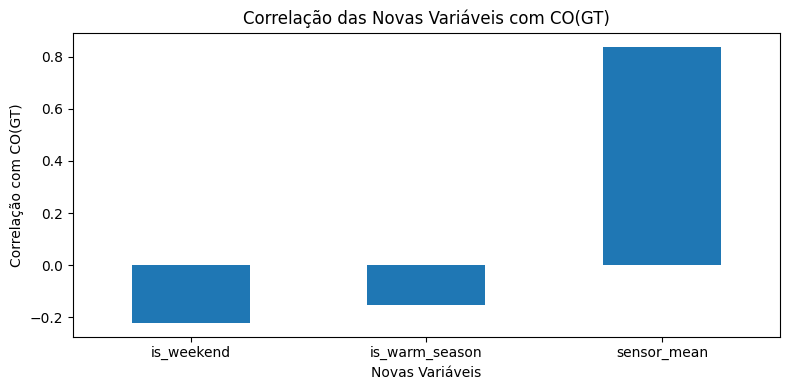

In [26]:
corr_target = corr_new_features["CO(GT)"].drop("CO(GT)")

plt.figure(figsize=(8, 4))
corr_target.plot(kind="bar")
plt.title("Correlação das Novas Variáveis com CO(GT)")
plt.xlabel("Novas Variáveis")
plt.ylabel("Correlação com CO(GT)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
df_clean[["CO(GT)", "is_weekend", "is_warm_season", "sensor_mean"]].head()

,CO(GT),is_weekend,is_warm_season,sensor_mean
0,2.6,0,0,1284.4
1,2.0,0,0,1190.4
2,2.2,0,0,1222.0
3,2.2,0,0,1240.6
4,1.6,0,0,1182.6


### Principais observações sobre os novos atributos

A criação de novos atributos permitiu enriquecer o conjunto de dados com informação adicional relevante para a análise e futura modelação.

A variável **`hour`** revelou-se particularmente útil para captar padrões ao longo do dia, sendo expectável que a concentração de poluentes varie consoante períodos de maior ou menor atividade urbana.

A variável **`day_of_week`**, em conjunto com **`is_weekend`**, permite distinguir comportamentos entre dias úteis e fins de semana, podendo refletir diferenças na intensidade do tráfego e da atividade industrial.

A variável **`month`** e o indicador **`is_warm_season`** introduzem uma componente sazonal na análise, possibilitando a identificação de padrões associados a diferentes épocas do ano, como variações de temperatura e condições atmosféricas.

Por fim, a variável **`sensor_mean`** sintetiza a informação proveniente dos vários sensores químicos, funcionando como um indicador agregado que pode ajudar a capturar tendências gerais na qualidade do ar.

De forma geral, os novos atributos contribuem para uma representação mais rica do fenómeno em estudo, podendo melhorar a capacidade preditiva dos modelos na fase de modelação.

## Seleção de Atributos

Nesta secção é analisada a correlação entre as variáveis preditoras, com o objetivo de identificar casos de multicolinearidade.

Optou-se por remover variáveis redundantes quando a correlação absoluta entre atributos é demasiado elevada, de forma a reduzir sobreposição de informação e melhorar a preparação do dataset para a modelação.

In [28]:
predictor_cols = [col for col in df_clean.select_dtypes(include=["number"]).columns if col != "CO(GT)"]

print("Número de variáveis preditoras numéricas consideradas:", len(predictor_cols))
predictor_cols

Número de variáveis preditoras numéricas consideradas: 32


['PT08.S1(CO)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH',
 'hour',
 'is_weekend',
 'is_warm_season',
 'sensor_mean',
 'day_of_week_Monday',
 'day_of_week_Saturday',
 'day_of_week_Sunday',
 'day_of_week_Thursday',
 'day_of_week_Tuesday',
 'day_of_week_Wednesday',
 'month_10',
 'month_11',
 'month_12',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9']

In [29]:
corr_matrix_features = df_clean[predictor_cols].corr().abs()

corr_matrix_features.head()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
PT08.S1(CO),1.000000,0.884386,0.888698,0.673478,0.804128,0.598189,0.667649,0.899833,0.031092,0.152240,...,0.036543,0.001686,0.030086,0.149603,0.044798,0.019597,0.107599,0.080531,0.148925,0.052640
C6H6(GT),0.884386,1.000000,0.988416,0.670597,0.781487,0.583920,0.760316,0.870064,0.204586,0.047822,...,0.086584,0.006964,0.108774,0.046022,0.015823,0.019316,0.031653,0.020846,0.115812,0.052065
PT08.S2(NMHC),0.888698,0.988416,1.000000,0.666552,0.819386,0.600060,0.768983,0.878386,0.231653,0.063630,...,0.076229,0.003741,0.109010,0.049596,0.024121,0.026267,0.036367,0.027141,0.102767,0.051303
NOx(GT),0.673478,0.670597,0.666552,1.000000,0.690218,0.780195,0.207676,0.751825,0.265014,0.212301,...,0.223648,0.227744,0.100920,0.005841,0.147209,0.182195,0.190580,0.171596,0.237079,0.032114
PT08.S3(NOx),0.804128,0.781487,0.819386,0.690218,1.000000,0.626668,0.527265,0.831771,0.095983,0.108983,...,0.064560,0.017296,0.041899,0.005833,0.112657,0.125182,0.072650,0.008849,0.020560,0.002755


In [30]:
upper_triangle = corr_matrix_features.where(
    np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notnull(corr_value) and corr_value > 0.90:
            high_corr_pairs.append((row, col, round(corr_value, 3)))

high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["Variável 1", "Variável 2", "Correlação"])

high_corr_pairs_df

,Variável 1,Variável 2,Correlação
0,C6H6(GT),PT08.S2(NMHC),0.988
1,PT08.S1(CO),sensor_mean,0.915
2,C6H6(GT),sensor_mean,0.944
3,PT08.S2(NMHC),sensor_mean,0.946


In [31]:
cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.90)]

print("Colunas sinalizadas para remoção por elevada correlação:", cols_to_drop)
print("Número de colunas a remover:", len(cols_to_drop))

Colunas sinalizadas para remoção por elevada correlação: ['PT08.S2(NMHC)', 'sensor_mean']
Número de colunas a remover: 2


In [32]:
df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

print("Dimensão final do dataset após seleção de atributos:", df_clean.shape)
display(df_clean.head())

Dimensão final do dataset após seleção de atributos: (7674, 31)


,CO(GT),PT08.S1(CO),C6H6(GT),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
0,2.6,1360.0,11.9,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,...,0,0,0,1,0,0,0,0,0,0
1,2.0,1292.0,9.4,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,...,0,0,0,1,0,0,0,0,0,0
2,2.2,1402.0,9.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,...,0,0,0,1,0,0,0,0,0,0
3,2.2,1376.0,9.2,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,...,0,0,0,1,0,0,0,0,0,0
4,1.6,1272.0,6.5,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,...,0,0,0,1,0,0,0,0,0,0


In [33]:
output_path = "/kaggle/working/airquality_processed.csv"
df_clean.to_csv(output_path, index=False)

print("Dataset processado guardado em:", output_path)
print("Dimensão final do dataset exportado:", df_clean.shape)

Dataset processado guardado em: /kaggle/working/airquality_processed.csv
Dimensão final do dataset exportado: (7674, 31)


### Principais observações sobre a seleção de atributos

A análise de multicolinearidade permitiu identificar variáveis preditoras com correlações muito elevadas, sugerindo redundância de informação.

Com base num limiar de correlação absoluta superior a 0.90, foram sinalizadas e removidas algumas colunas redundantes, reduzindo a complexidade do dataset final.

Após esta etapa, o conjunto de dados ficou preparado para a fase seguinte de modelação, tendo sido exportado para ficheiro CSV.
